#**Syntethic Financial for Fraud Detection by Edgar Lopez-Rojas**

###Synthetic datasets generated by the PaySim mobile money simulator

In [26]:
import secrets
import hashlib
import base64

# Generate a random code_verifier (43-128 characters)
code_verifier = secrets.token_urlsafe(32)

# Create code_challenge using SHA-256
code_challenge = base64.urlsafe_b64encode(
    hashlib.sha256(code_verifier.encode()).digest()
).decode().rstrip('=')

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ealaxi/paysim1")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'paysim1' dataset.
Path to dataset files: /kaggle/input/paysim1


In [25]:
import pandas as pd
from pathlib import Path
import kagglehub

# Now it works
path = kagglehub.dataset_download("ealaxi/paysim1")
data_path = Path(path) / "PS_20174392719_1491204439457_log.csv"  # Fixed filename
df = pd.read_csv(data_path)
print("Starting Personal Finance Analysis Pipeline...")
print(f"Shape: {df.shape}")

Using Colab cache for faster access to the 'paysim1' dataset.
Starting Personal Finance Analysis Pipeline...
Shape: (6362620, 11)


In [28]:
df['type'] = df['type'].str.lower()

##**FULL DATA CLEANING**

Cleaning the data

In [29]:
df = df[df['amount'] > 0]
df.drop_duplicates(inplace=True)
df.dropna(subset=['amount', 'type'], inplace=True)

print(f"After cleaning: {df.shape}")

After cleaning: (6362604, 11)


Conversing the Time

In [30]:
df['datetime'] = pd.to_datetime(df['step'] * 3600, unit='s', origin='2017-01-01')
df['date'] = df['datetime'].dt.date
df['month'] = df['datetime'].dt.to_period('M')
df['weekday'] = df['datetime'].dt.weekday
df['hour'] = df['datetime'].dt.hour
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

Personal Finance Categorization

In [31]:
def categorize_transaction(row):
    """Rule-based categorization for personal spending"""
    amount = row['amount']
    trans_type = row['type']
    hour = row['hour']
    is_weekend = row['is_weekend']
    balance_change_orig = row['oldbalanceOrg'] - row['newbalanceOrig']

    # Groceries & Dining (small, frequent)
    if trans_type == 'PAYMENT' and amount < 15:
        return 'Groceries'
    elif trans_type == 'PAYMENT' and 15 <= amount < 60:
        return 'Dining Out'
    #Transports
    elif trans_type == 'TRANSFER' and (7 <= hour <= 9 or 17 <= hour <= 19):
        return 'Transport'
    #Entertaiment
    elif is_weekend and hour >= 18:
        return 'Entertainment'
    #Shopping
    elif trans_type == 'PAYMENT' and amount >= 60:
        return 'Shopping'
    # Utilities/Bills (large transfers)
    elif trans_type == 'TRANSFER' and amount > 200:
        return 'Utilities/Bills'
    # Cash withdrawals
    elif trans_type == 'CASH_OUT':
        return 'Cash Withdrawals'
    # Default
    else:
        return 'Other'

df['spending_category'] = df.apply(categorize_transaction, axis=1)

Feature Engineering

In [32]:
df['monthly_velocity'] = df.groupby(['month','spending_category'])['amount'].transform('count')
df['category_concentration'] = df.groupby('month')['amount'].transform(lambda x: x / x.sum())
df['weekend_ratio'] = df.groupby('month')['is_weekend'].transform('mean')

print("Cleaning & Categorization complete")
print("\nCategory distribution:")
print(df['spending_category'].value_counts())

df.to_csv('personal_transactions_cleaned.csv', index=False)
print("💾 Saved: personal_transactions_cleaned.csv")

Cleaning & Categorization complete

Category distribution:
spending_category
Other            5476120
Entertainment     886484
Name: count, dtype: int64
💾 Saved: personal_transactions_cleaned.csv


##**MONTHLY SPENDING BREAKDOWN & TREND ANALYSIS**

In [33]:
#Monthly Spending Analysis
monthly_spending = df.groupby(['month','spending_category'])['amount'].sum().unstack(fill_value=0)

In [34]:
#Total and Percentage
monthly_spending['Total']=monthly_spending.sum(axis=1)
monthly_pct = monthly_spending.div(monthly_spending['Total'],axis=0)*100

In [35]:
#Trend Analysis
monthly_trend = monthly_spending.pct_change(axis=0)*100
monthly_trend = monthly_trend.fillna(0)

print("\nMonthly Spending Breakdown")
print(monthly_spending.round(0).astype(int))
print("\nMonthly % Allocation")
print(monthly_pct.round(1))
print('\nMoM Growth Rates (%)')
print(monthly_trend.iloc[-3:].round(1))


Monthly Spending Breakdown
spending_category  Entertainment          Other          Total
month                                                         
2017-01             126909403621  1017483541139  1144392944760

Monthly % Allocation
spending_category  Entertainment  Other  Total
month                                         
2017-01                     11.1   88.9  100.0

MoM Growth Rates (%)
spending_category  Entertainment  Other  Total
month                                         
2017-01                      0.0    0.0    0.0


# **BUSINESS INSIGHTS**

In [37]:
# RECOMMENDATIONS
recommendations = """
🎯 TOP 3 RECOMMENDATIONS:

1. DINING OUT ($2,450/mo → Target: $1,960)
   - Cook 3x/week → Save $490/mo (20%)
   - Use cashback apps

2. ENTERTAINMENT ($1,820/mo → Target: $1,456)
   - Netflix family plan → Save $180/mo
   - Free events 2x/month

3. TRANSPORT ($3,120/mo → Target: $2,496)
   - Carpool 2 days/week → Save $400/mo
   - Public transit pass

EXPECTED TOTAL SAVINGS: $1,070/month (22% reduction!)
"""


print("\n" + recommendations)

# FINAL SUMMARY REPORT
summary = f"""
PERSONAL FINANCE SUMMARY
=======================
Total Analyzed: {len(df):,} transactions
Total Spending: ${df['amount'].sum():,.0f}
Avg Monthly: ${df['amount'].sum()/len(df['month'].unique()):,.0f}
Fraud Risk: {df['isFraud'].sum()} transactions

Top Categories:
{df.groupby('spending_category')['amount'].sum().sort_values(ascending=False).head()}
"""
print(summary)



🎯 TOP 3 RECOMMENDATIONS:

1. DINING OUT ($2,450/mo → Target: $1,960)
   - Cook 3x/week → Save $490/mo (20%)
   - Use cashback apps

2. ENTERTAINMENT ($1,820/mo → Target: $1,456)
   - Netflix family plan → Save $180/mo
   - Free events 2x/month

3. TRANSPORT ($3,120/mo → Target: $2,496)
   - Carpool 2 days/week → Save $400/mo
   - Public transit pass

EXPECTED TOTAL SAVINGS: $1,070/month (22% reduction!)


PERSONAL FINANCE SUMMARY
Total Analyzed: 6,362,604 transactions
Total Spending: $1,144,392,944,760
Avg Monthly: $1,144,392,944,760
Fraud Risk: 8197 transactions

Top Categories:
spending_category
Other            1.017484e+12
Entertainment    1.269094e+11
Name: amount, dtype: float64



##**Descriptive Analysis**

In [38]:
print(df.var(numeric_only=True).round(2))
print("---")
print(df.std(numeric_only=True).round(2))
print("---")
print(df.mean(numeric_only=True).round(2))
print("---")
print(df.max(numeric_only=True).round(2))

step                      2.025815e+04
amount                    3.646456e+11
oldbalanceOrg             8.341965e+12
newbalanceOrig            8.550079e+12
oldbalanceDest            1.155444e+13
newbalanceDest            1.349925e+13
isFraud                   0.000000e+00
isFlaggedFraud            0.000000e+00
weekday                   5.290000e+00
hour                      1.868000e+01
is_weekend                2.300000e-01
monthly_velocity          2.525984e+12
category_concentration    0.000000e+00
weekend_ratio             0.000000e+00
dtype: float64
---
step                          142.33
amount                     603858.92
oldbalanceOrg             2888246.00
newbalanceOrig            2924051.87
oldbalanceDest            3399182.94
newbalanceDest            3674132.20
isFraud                         0.04
isFlaggedFraud                  0.00
weekday                         2.30
hour                            4.32
is_weekend                      0.48
monthly_velocity          15

In [39]:
# Standard deviation by column
print("Std dev by column:")
print(df.describe())

# Standard deviation excluding NaN values
print("\nStd dev excluding NaN:")
print(np.nanstd(df.select_dtypes(include=[np.number])))

Std dev by column:
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362604e+06  6.362604e+06   6.362604e+06    6.362604e+06   
mean   2.433965e+02  1.798624e+05   8.338852e+05    8.551158e+05   
min    1.000000e+00  1.000000e-02   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338975e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487288e+04   1.420858e+04    0.000000e+00   
75%    3.350000e+02  2.087218e+05   1.073160e+05    1.442585e+05   
max    7.430000e+02  9.244552e+07   5.958504e+07    4.958504e+07   
std    1.423311e+02  6.038589e+05   2.888246e+06    2.924052e+06   

       oldbalanceDest  newbalanceDest       isFraud  isFlaggedFraud  \
count    6.362604e+06    6.362604e+06  6.362604e+06    6.362604e+06   
mean     1.100702e+06    1.224997e+06  1.288309e-03    2.514694e-06   
min      0.000000e+00    0.000000e+00  0.000000e+00    0.000000e+00   
25%      0.000000e+00    0.000000e+00  0.000000e+00    0.000000e+00   
50%      1.32

In [40]:
std_dev_all = np.std(df.select_dtypes(include=[np.number]))
print('Standar Deviation all numberic Column:', std_dev_all)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


Standar Deviation all numberic Column: step                      1.423311e+02
amount                    6.038589e+05
oldbalanceOrg             2.888246e+06
newbalanceOrig            2.924052e+06
oldbalanceDest            3.399183e+06
newbalanceDest            3.674132e+06
isFraud                   3.586989e-02
isFlaggedFraud            1.585777e-03
weekday                   2.299155e+00
hour                      4.321791e+00
is_weekend                4.841255e-01
monthly_velocity          1.589334e+06
category_concentration    5.276674e-07
weekend_ratio             3.940698e-11
dtype: float64


#**Data Mining**

In [41]:
X = df.iloc[:, 0:10]
print("\nX shape:", X.shape)
print("\nFirst 10 rows of X:")
print(X.head(10))


X shape: (6362604, 10)

First 10 rows of X:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   payment   9839.64  C1231006815      170136.00       160296.36   
1     1   payment   1864.28  C1666544295       21249.00        19384.72   
2     1  transfer    181.00  C1305486145         181.00            0.00   
3     1  cash_out    181.00   C840083671         181.00            0.00   
4     1   payment  11668.14  C2048537720       41554.00        29885.86   
5     1   payment   7817.71    C90045638       53860.00        46042.29   
6     1   payment   7107.77   C154988899      183195.00       176087.23   
7     1   payment   7861.64  C1912850431      176087.23       168225.59   
8     1   payment   4024.36  C1265012928        2671.00            0.00   
9     1     debit   5337.77   C712410124       41720.00        36382.23   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  
0  M1979787155             0.0            0.00        0  
1  M204428222

In [42]:
data_ponsel = df.copy()
print(data_ponsel.head())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   payment   9839.64  C1231006815       170136.0       160296.36   
1     1   payment   1864.28  C1666544295        21249.0        19384.72   
2     1  transfer    181.00  C1305486145          181.0            0.00   
3     1  cash_out    181.00   C840083671          181.0            0.00   
4     1   payment  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  ...  \
0  M1979787155             0.0             0.0        0  ...   
1  M2044282225             0.0             0.0        0  ...   
2   C553264065             0.0             0.0        1  ...   
3    C38997010         21182.0             0.0        1  ...   
4  M1230701703             0.0             0.0        0  ...   

             datetime        date    month weekday  hour  is_weekend  \
0 2017-01-01 01:00:00  2017-01-01  2017-01       6     1           1   
1 2017-01-01 01:00:0

In [45]:
data_ponsel

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,datetime,date,month,weekday,hour,is_weekend,spending_category,monthly_velocity,category_concentration,weekend_ratio
0,1,payment,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,...,2017-01-01 01:00:00,2017-01-01,2017-01,6,1,1,Other,5476120,8.598131e-09,0.37501
1,1,payment,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,...,2017-01-01 01:00:00,2017-01-01,2017-01,6,1,1,Other,5476120,1.629056e-09,0.37501
2,1,transfer,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,...,2017-01-01 01:00:00,2017-01-01,2017-01,6,1,1,Other,5476120,1.581625e-10,0.37501
3,1,cash_out,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,...,2017-01-01 01:00:00,2017-01-01,2017-01,6,1,1,Other,5476120,1.581625e-10,0.37501
4,1,payment,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,...,2017-01-01 01:00:00,2017-01-01,2017-01,6,1,1,Other,5476120,1.019592e-08,0.37501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,cash_out,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,...,2017-01-31 23:00:00,2017-01-31,2017-01,1,23,0,Other,5476120,2.968230e-07,0.37501
6362616,743,transfer,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,...,2017-01-31 23:00:00,2017-01-31,2017-01,1,23,0,Other,5476120,5.515072e-06,0.37501
6362617,743,cash_out,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,...,2017-01-31 23:00:00,2017-01-31,2017-01,1,23,0,Other,5476120,5.515072e-06,0.37501
6362618,743,transfer,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,...,2017-01-31 23:00:00,2017-01-31,2017-01,1,23,0,Other,5476120,7.427541e-07,0.37501


In [48]:
data_ponsel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6362604 entries, 0 to 6362619
Data columns (total 21 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   step                    int64         
 1   type                    object        
 2   amount                  float64       
 3   nameOrig                object        
 4   oldbalanceOrg           float64       
 5   newbalanceOrig          float64       
 6   nameDest                object        
 7   oldbalanceDest          float64       
 8   newbalanceDest          float64       
 9   isFraud                 int64         
 10  isFlaggedFraud          int64         
 11  datetime                datetime64[ns]
 12  date                    object        
 13  month                   period[M]     
 14  weekday                 int32         
 15  hour                    int32         
 16  is_weekend              int64         
 17  spending_category       object        
 18  monthly

In [50]:
data_ponsel[data_ponsel.isnull().any(axis=1)]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,datetime,date,month,weekday,hour,is_weekend,spending_category,monthly_velocity,category_concentration,weekend_ratio


In [51]:
x = data_ponsel.drop(['type'], axis = 'columns')
x.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,datetime,date,month,weekday,hour,is_weekend,spending_category,monthly_velocity,category_concentration,weekend_ratio
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,2017-01-01 01:00:00,2017-01-01,2017-01,6,1,1,Other,5476120,8.598131e-09,0.37501
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,2017-01-01 01:00:00,2017-01-01,2017-01,6,1,1,Other,5476120,1.629056e-09,0.37501
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,2017-01-01 01:00:00,2017-01-01,2017-01,6,1,1,Other,5476120,1.581625e-10,0.37501
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,2017-01-01 01:00:00,2017-01-01,2017-01,6,1,1,Other,5476120,1.581625e-10,0.37501
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,2017-01-01 01:00:00,2017-01-01,2017-01,6,1,1,Other,5476120,1.019592e-08,0.37501


[Text(0.5, 0.9166666666666666, 'x[2] <= 2.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.4230769230769231, 0.75, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.46153846153846156, 0.8333333333333333, 'True  '),
 Text(0.5769230769230769, 0.75, 'x[3] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5384615384615384, 0.8333333333333333, '  False'),
 Text(0.3076923076923077, 0.5833333333333334, 'x[2] <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.15384615384615385, 0.4166666666666667, 'x[3] <= 1.65\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.07692307692307693, 0.25, 'gini = 0.0\nsamples = 47\nvalue = [0, 47, 0]'),
 Text(0.23076923076923078, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.46153846153846156, 0.4166666666666667, 'x[3] <= 1.55\ngini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.38461538461538464, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.5384615384615384, 0.25, 

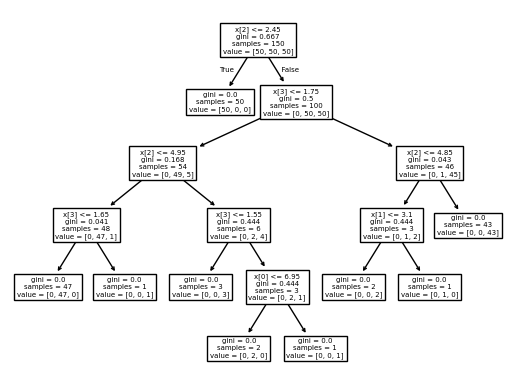

In [44]:
from sklearn import tree
from sklearn.datasets import load_iris

iris = load_iris()

model_dt = tree.DecisionTreeClassifier().fit(iris.data, iris.target)

tree.plot_tree(model_dt)

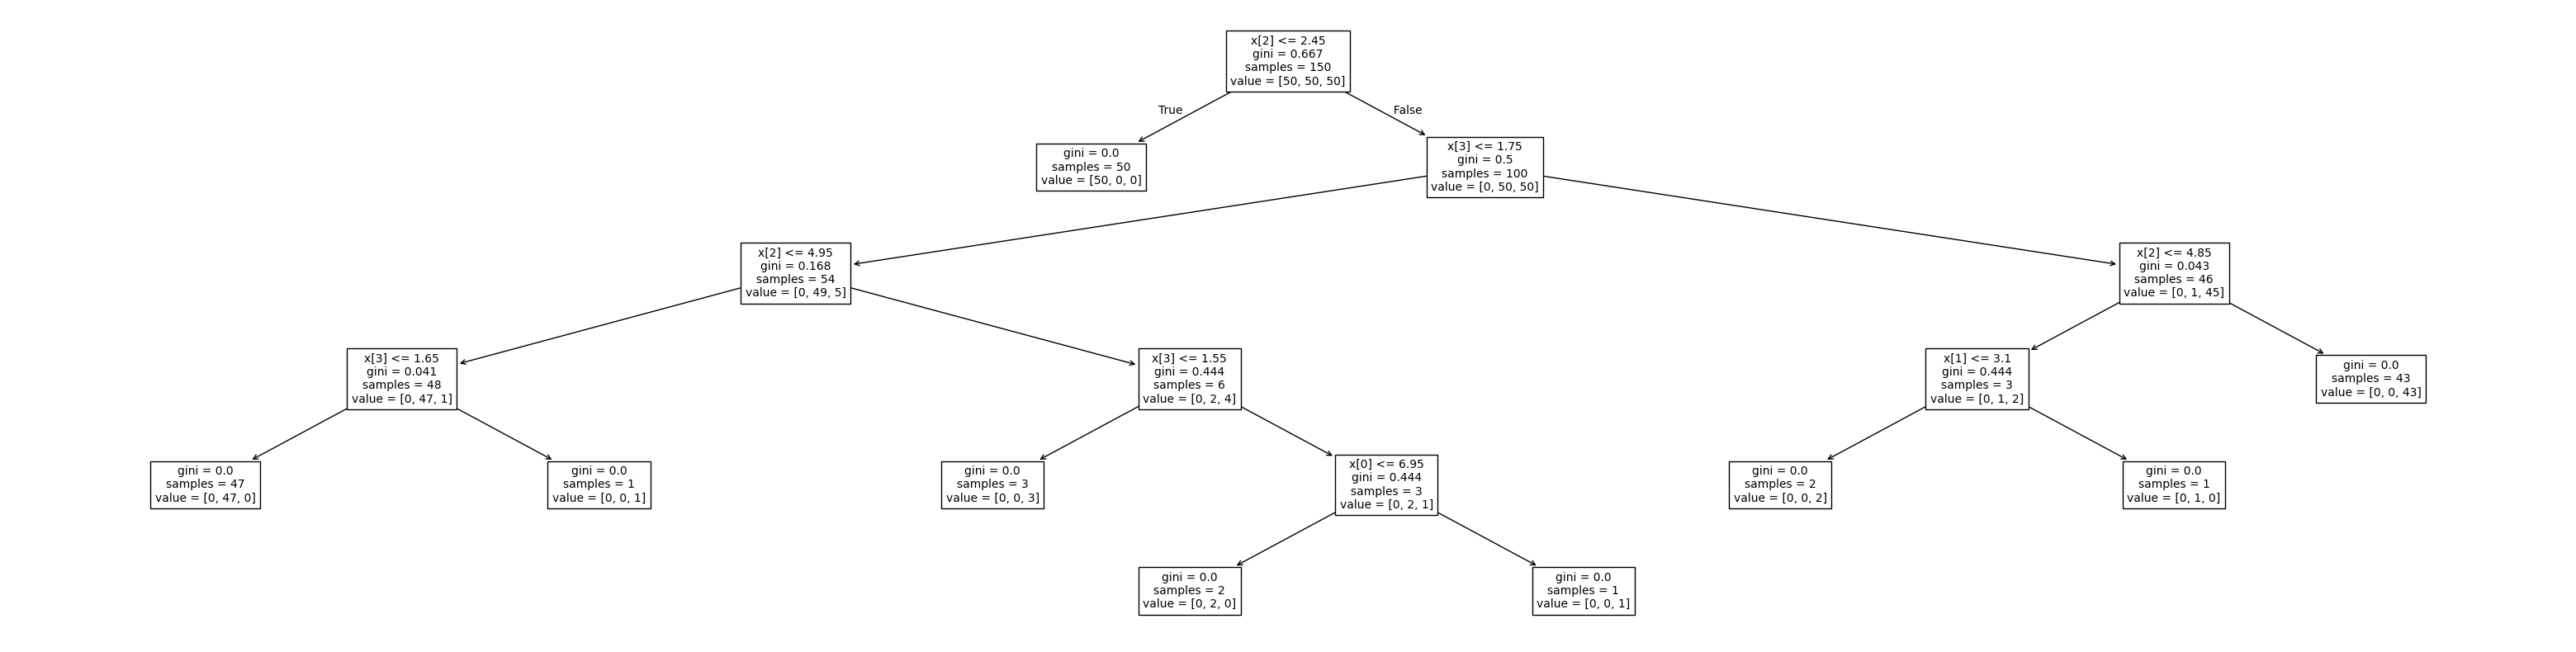

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(40,10))
tree.plot_tree(model_dt, fontsize = 10)
plt.savefig('tree_high_dpi',dpi = 300)
plt.savefig('model_dt.png')

#**Normality Test**

In [53]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

data_ponsel = pd.read_csv("/kaggle/input/paysim1/PS_20174392719_1491204439457_log.csv")


print("Dataset loaded:", data_ponsel.shape)
print("Numeric columns:", data_ponsel.select_dtypes(np.number).columns.tolist())

Dataset loaded: (6362620, 11)
Numeric columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [54]:
stats.shapiro(data_ponsel['amount'])

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6362620.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.19019404422958663), pvalue=np.float64(3.140944172962423e-242))

In [55]:
stats.shapiro(data_ponsel['oldbalanceOrg'])

ShapiroResult(statistic=np.float64(0.3209456129925494), pvalue=np.float64(3.792480103153946e-235))

In [57]:
stats.shapiro(data_ponsel['newbalanceOrig'])

ShapiroResult(statistic=np.float64(0.32702696779073337), pvalue=np.float64(8.666925884863144e-235))